### Práctica 4: Algoítmos para funciones de varias variables

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

#  4.1 Optimización para una función no derivable. pero convexa

In [11]:
def objective(v):
    x, y = v
    f = np.sqrt(x**2 + y**2)
    return f

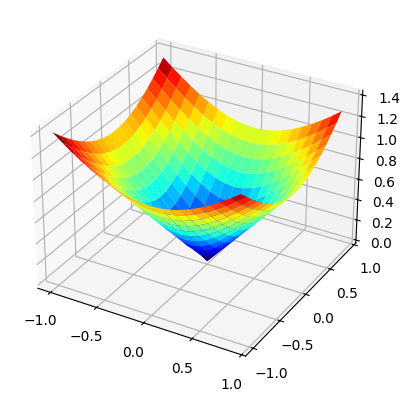

In [16]:
r_min, r_max = -1.0, 1.0
xaxis = np.arange(r_min, r_max, 0.1)
yaxis = np.arange(r_min, r_max, 0.1)
x, y = np.meshgrid(xaxis, yaxis)
v= x, y
results = objective(v)
fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
ax.plot_surface(x, y, results, cmap='jet')
plt.show()

In [8]:
from scipy.optimize import minimize

In [29]:
initial_guess = r_min + np.random.rand(2) * (r_max-r_min)
#               num   +  vector_alea_0-1  *    numero
#                 broadcast
result = minimize(objective, initial_guess, method='powell')
print(f'Estado: {result['message']}')
print(f'número de evaluaciones de la función objetivo: {result['nfev']}')
solution = result['x']
evaluation = objective(solution)
print(f'Solución f{solution} = {evaluation:.5f}')

Estado: Optimization terminated successfully.
número de evaluaciones de la función objetivo: 283
Solución f[-3.97123666e-12  2.51761518e-12] = 0.00000


# Optimización de una función diferenciable pero no convexa

In [110]:
def ackley(v):
    x, y = v
    f = -20.0 * np.exp(-0.2 * np.sqrt(0.5*(x**2+y**2))) - np.exp(0.5*(np.cos(2*np.pi*x) + np.cos(2*np.pi*y))) + np.exp(1) + 20
    return f

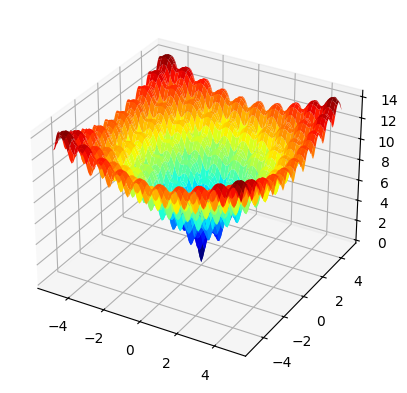

In [111]:
r_min, r_max = -5.0, 5.0
xaxis = np.arange(r_min, r_max, 0.1)
yaxis = np.arange(r_min, r_max, 0.1)
x, y = np.meshgrid(xaxis, yaxis)
v= x, y
results = ackley(v)

fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
ax.plot_surface(x, y, results, cmap='jet')
plt.show()

In [112]:
initial_guess = r_min + np.random.rand(2) * (r_max-r_min)
#               num   +  vector_alea_0-1  *    numero
#                 broadcast
result = minimize(ackley, initial_guess, method='powell')
print(f'Estado: {result['message']}')
print(f'número de evaluaciones de la función objetivo: {result['nfev']}')
solution = result['x']
evaluation = ackley(solution)
print(f'Solución f{solution} = {evaluation:.5f}')

Estado: Optimization terminated successfully.
número de evaluaciones de la función objetivo: 238
Solución f[4.08036135e-12 1.01639502e-13] = 0.00000


# Problemas con restricciones

In [124]:
def objective(x):
    x1 = x[0]
    x2 = x[1]
    return 4*(x1**2)+x2**2-x1-2*x2

In [115]:
def restric1(x):
    return -2*x[0]-x[1]+1  # Estandar en menor que
def restric2(x):
    return 1 - x[0]**2

In [127]:
x0 = (1, 0)
con1 = {'type': 'ineq', 'fun': restric1}
con2 = {'type': 'ineq', 'fun': restric2}
cons = [con1, con2]

sol = minimize(objective, x0, constraints=cons)
print(f'solución = {sol.x}')
print(f'calor de la función objetivo en el mínimo: {objective(sol.x)}')

solución = [0.0625     0.87500001]
calor de la función objetivo en el mínimo: -1.03125
